Cobertura de etiquetas por experto:


,quality_non_null,quality_unique,cough_type_non_null,cough_type_unique
Experto 1,820,4,802,3
Experto 2,820,4,801,3
Experto 3,820,4,795,3
Experto 4,820,4,801,3


C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\4193341096.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=values, order=order, ax=ax, palette='viridis')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\4193341096.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=values, order=order, ax=ax, palette='viridis')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\4193341096.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=values, order=order, ax=ax, palette='viridis')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_

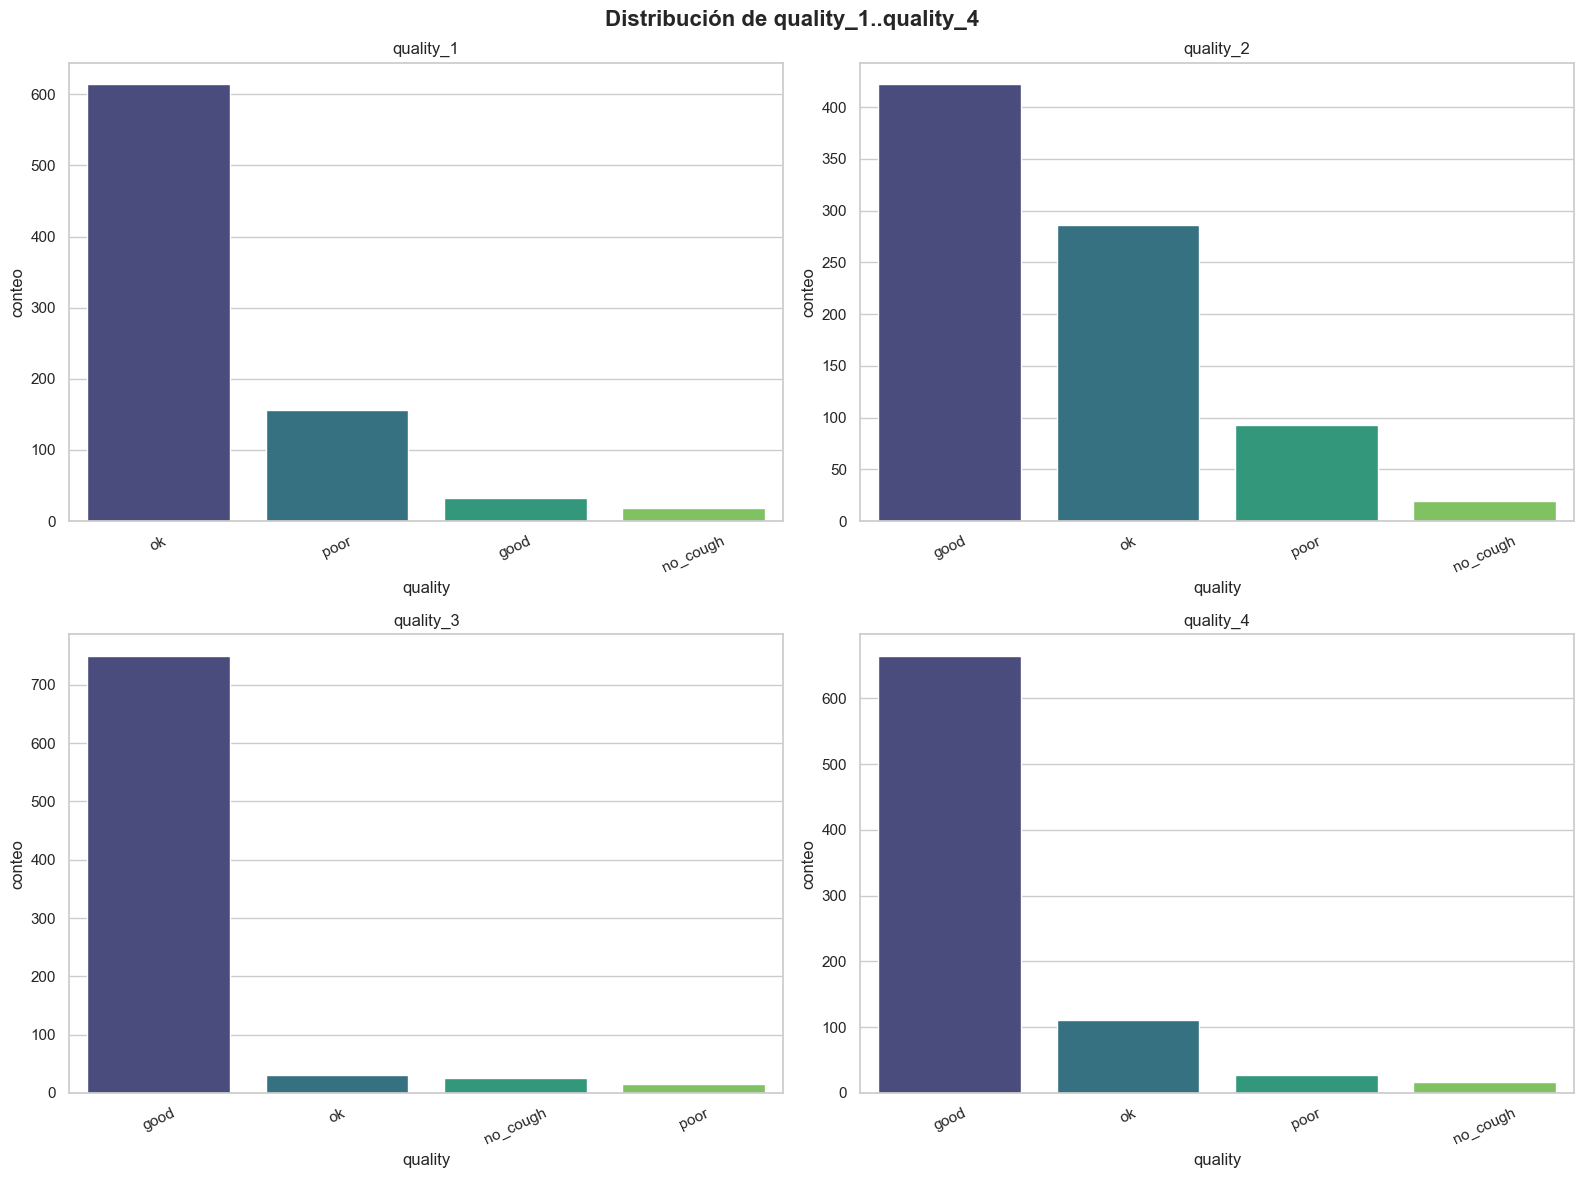

C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\4193341096.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=values, order=order, ax=ax, palette='magma')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\4193341096.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=values, order=order, ax=ax, palette='magma')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\4193341096.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=values, order=order, ax=ax, palette='magma')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\

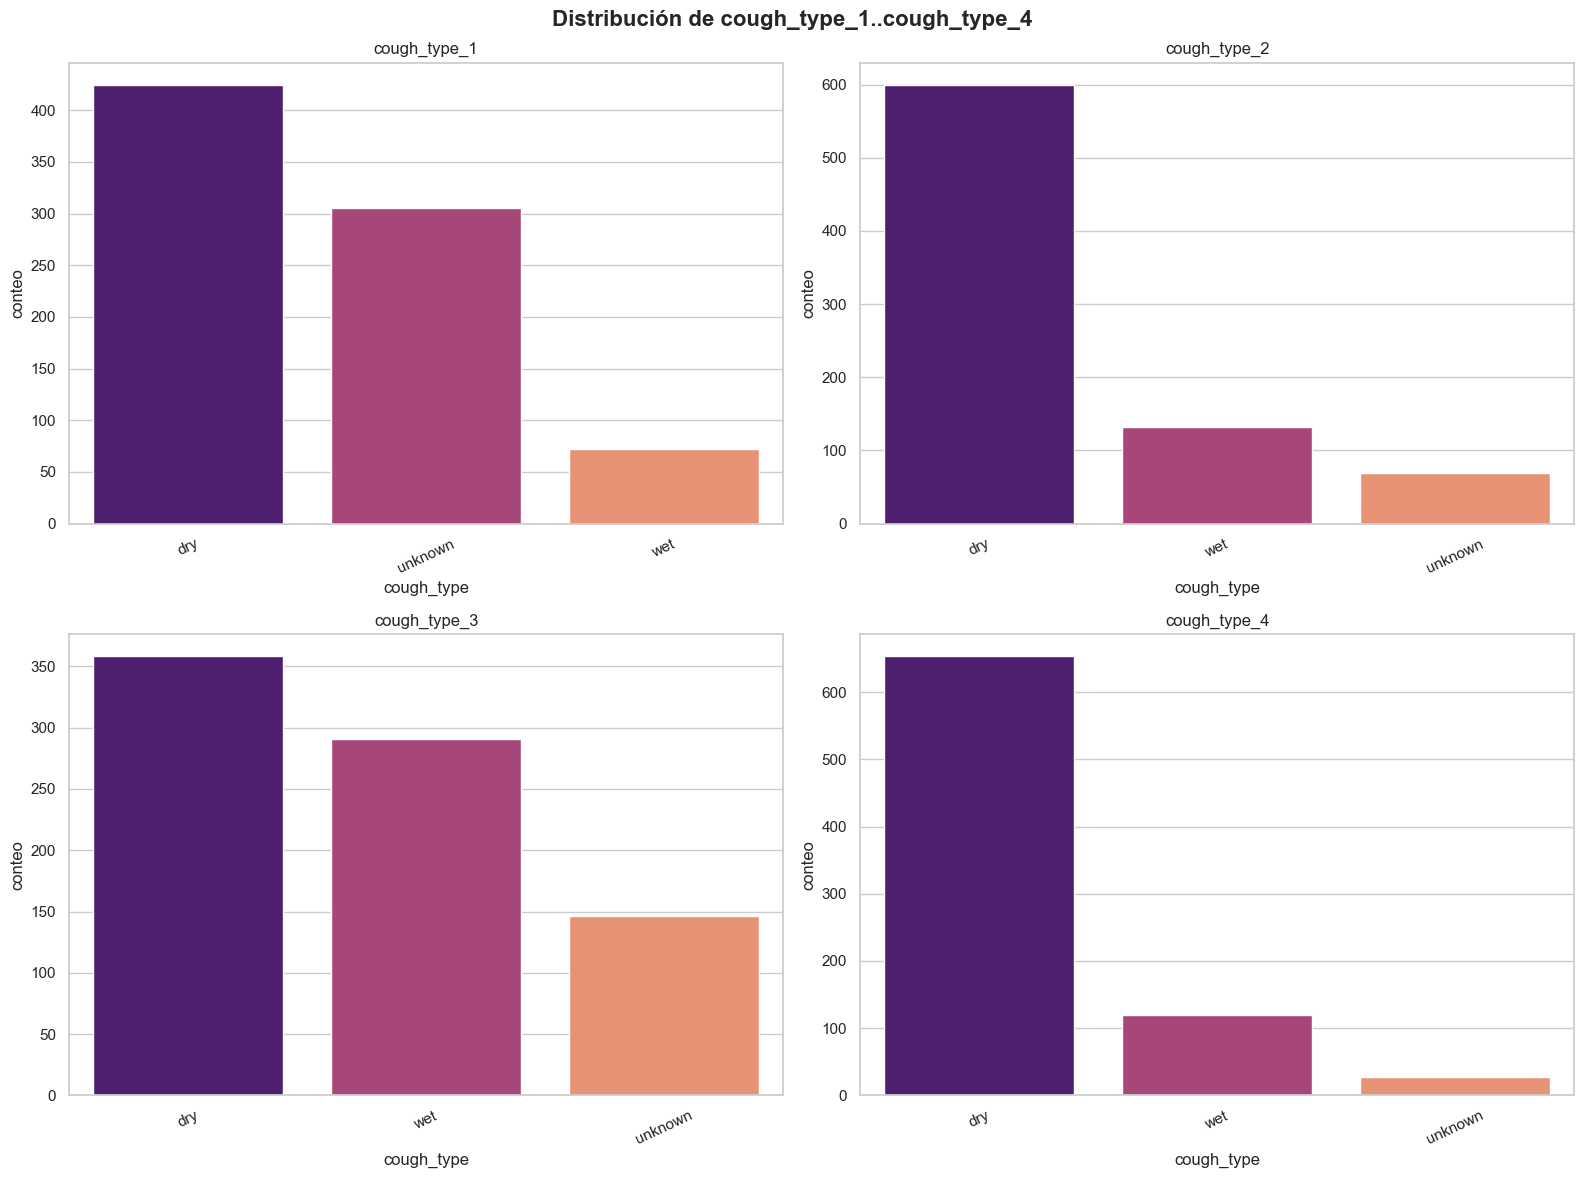

C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\4193341096.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=quality_all, order=quality_all.value_counts().index, ax=axes[0], palette='Blues')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\4193341096.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=cough_type_all, order=cough_type_all.value_counts().index, ax=axes[1], palette='Reds')


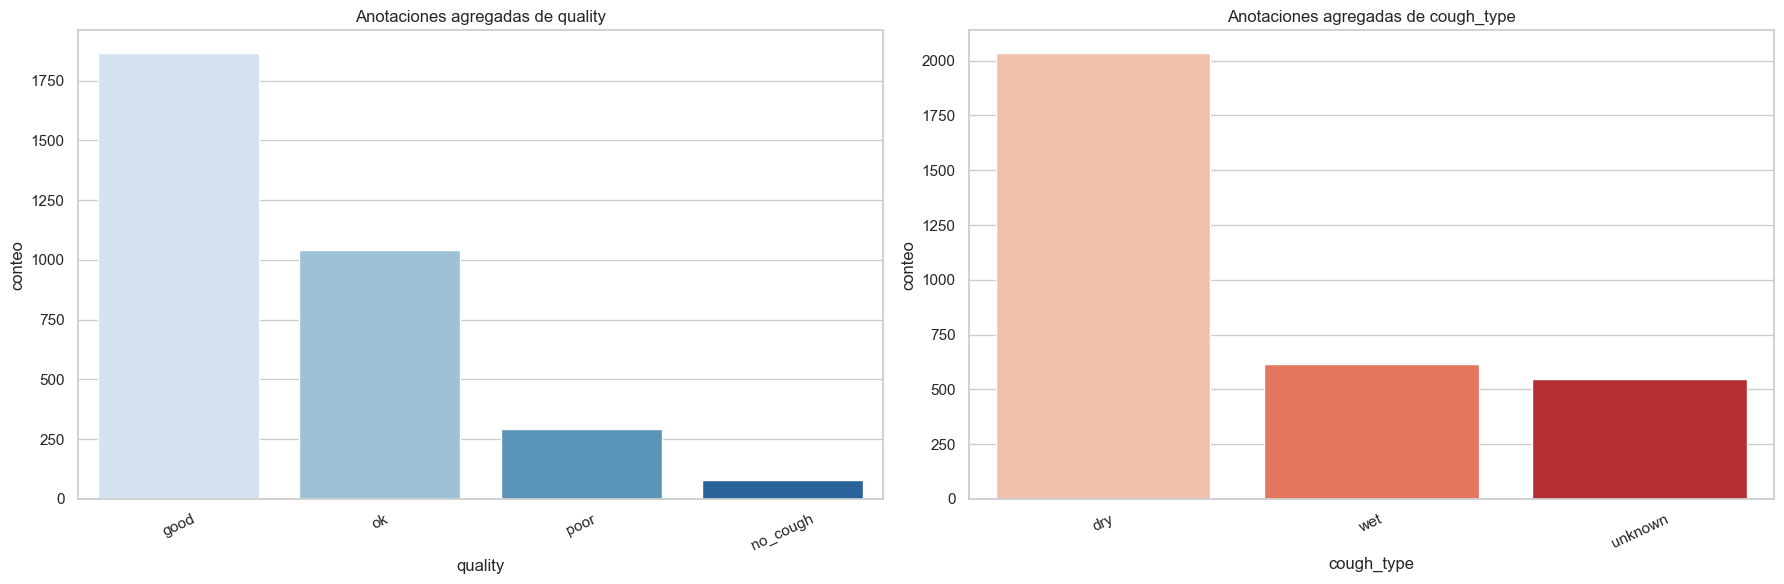

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import numpy as np

# Cargar el dataset base
csv_path = '../../DATA/metadata_compiled.csv'
df = pd.read_csv(csv_path)

quality_cols = [f'quality_{i}' for i in range(1, 5)]
cough_type_cols = [f'cough_type_{i}' for i in range(1, 5)]

def clean_values(series):
    values = series.dropna().astype(str).str.strip().str.lower()
    return values.replace({'': 'unknown', 'none': 'unknown', 'nan': 'unknown'})

# Resumen rápido de cobertura por experto
summary = pd.DataFrame({
    'quality_non_null': [df[col].notna().sum() for col in quality_cols],
    'quality_unique': [df[col].dropna().astype(str).str.strip().str.lower().nunique() for col in quality_cols],
    'cough_type_non_null': [df[col].notna().sum() for col in cough_type_cols],
    'cough_type_unique': [df[col].dropna().astype(str).str.strip().str.lower().nunique() for col in cough_type_cols],
}, index=[f'Experto {i}' for i in range(1, 5)])

print('Cobertura de etiquetas por experto:')
display(summary)

sns.set_theme(style='whitegrid')

# Distribución de quality_1..quality_4
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribución de quality_1..quality_4', fontsize=16, fontweight='bold')
for ax, col in zip(axes.flat, quality_cols):
    values = clean_values(df[col])
    order = values.value_counts().index
    sns.countplot(x=values, order=order, ax=ax, palette='viridis')
    ax.set_title(col)
    ax.set_xlabel('quality')
    ax.set_ylabel('conteo')
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

# Distribución de cough_type_1..cough_type_4
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribución de cough_type_1..cough_type_4', fontsize=16, fontweight='bold')
for ax, col in zip(axes.flat, cough_type_cols):
    values = clean_values(df[col])
    order = values.value_counts().index
    sns.countplot(x=values, order=order, ax=ax, palette='magma')
    ax.set_title(col)
    ax.set_xlabel('cough_type')
    ax.set_ylabel('conteo')
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

# Vista agregada de todas las anotaciones expertas
quality_all = pd.concat([clean_values(df[col]) for col in quality_cols], ignore_index=True)
cough_type_all = pd.concat([clean_values(df[col]) for col in cough_type_cols], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.countplot(x=quality_all, order=quality_all.value_counts().index, ax=axes[0], palette='Blues')
axes[0].set_title('Anotaciones agregadas de quality')
axes[0].set_xlabel('quality')
axes[0].set_ylabel('conteo')
axes[0].tick_params(axis='x', rotation=25)

sns.countplot(x=cough_type_all, order=cough_type_all.value_counts().index, ax=axes[1], palette='Reds')
axes[1].set_title('Anotaciones agregadas de cough_type')
axes[1].set_xlabel('cough_type')
axes[1].set_ylabel('conteo')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

In [6]:
# Quedarnos solo con las filas que tienen al menos una etiqueta de experto
expert_cols = quality_cols + cough_type_cols

df_expert = df[df[expert_cols].notna().any(axis=1)].copy()

print(f"Total de filas en metadata_compiled: {len(df)}")
print(f"Total de filas con al menos una etiqueta de experto: {len(df_expert)}")

# Mostrar una vista previa del DataFrame filtrado
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
display(df_expert)





Total de filas en metadata_compiled: 27550
Total de filas con al menos una etiqueta de experto: 2890


,uuid,datetime,cough_detected,SNR,latitude,longitude,age,gender,respiratory_condition,fever_muscle_pain,status,quality_1,cough_type_1,dyspnea_1,wheezing_1,stridor_1,choking_1,congestion_1,nothing_1,diagnosis_1,severity_1,quality_2,cough_type_2,dyspnea_2,wheezing_2,stridor_2,choking_2,congestion_2,nothing_2,diagnosis_2,severity_2,quality_3,cough_type_3,dyspnea_3,wheezing_3,stridor_3,choking_3,congestion_3,nothing_3,diagnosis_3,severity_3,quality_4,cough_type_4,dyspnea_4,wheezing_4,stridor_4,choking_4,congestion_4,nothing_4,diagnosis_4,severity_4
12,0029d048-898a-4c70-89c7-0815cdcf7391,2020-07-16T03:01:55.059762+00:00,1.0,9.624196,NaN,NaN,35.0,male,True,False,symptomatic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,good,dry,False,False,False,False,False,True,upper_infection,mild
14,002db0bd-e57f-4c30-ade0-16640d424eb7,2020-04-13T19:51:11.397697+00:00,1.0,6.781094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,good,unknown,False,False,False,False,False,True,healthy_cough,pseudocough,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33,005b8518-03ba-4bf5-86d2-005541442357,2020-04-14T20:16:53.677536+00:00,1.0,17.428288,45.2,19.7,23.0,female,False,False,healthy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,good,dry,False,False,False,False,False,True,lower_infection,mild,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41,006d8d1c-2bf6-46a6-8ef2-1823898a4733,2020-04-22T10:24:21.408615+00:00,1.0,13.284361,NaN,NaN,28.0,male,True,True,symptomatic,ok,dry,False,False,False,False,False,True,healthy_cough,pseudocough,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,008ba489-31ad-44d8-856b-fcf72369dc46,2020-04-13T23:09:36.585124+00:00,1.0,12.711530,38.1,-122.2,28.0,female,False,False,healthy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,good,wet,False,False,True,False,False,False,lower_infection,mild,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27529,ffbeb867-cdb7-4226-9456-e74c80acf2d9,2020-04-25T01:42:52.162671+00:00,1.0,11.193300,NaN,NaN,30.0,male,False,False,symptomatic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,good,wet,False,False,False,False,False,True,upper_infection,mild,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27532,ffc99580-678c-46c3-8e3f-c2a19916657d,2020-04-14T20:58:12.567436+00:00,0.0,15.911958,43.3,-3.2,NaN,NaN,NaN,NaN,NaN,no_cough,NaN,False,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27534,ffd18a56-096d-40fc-9862-e5c5a8ca1fcd,2020-04-14T05:56:02.587585+00:00,1.0,12.290065,46.5,6.6,25.0,female,False,False,healthy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ok,dry,False,False,False,False,False,True,COVID-19,mild
27539,ffe0658f-bade-4654-ad79-40a468aabb03,2020-04-14T01:58:32.200245+00:00,1.0,21.960583,41.6,60.9,22.0,male,True,True,COVID-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,poor,unknown,False,False,False,False,False,False,NaN,unknown


In [10]:
base_expert_vars = [
    'quality', 'cough_type', 'dyspnea', 'wheezing', 'stridor', 
    'choking', 'congestion', 'nothing', 'diagnosis', 'severity'
]

# Creamos una copia para no alterar el df_expert original por si acaso
df_unified = df_expert.copy()

# 2. Iteramos sobre cada variable base para colapsar sus versiones _1, _2, _3, _4
for var in base_expert_vars:
    # Generamos la lista de las 4 columnas específicas para esta variable
    expert_cols_for_var = [f"{var}_1", f"{var}_2", f"{var}_3", f"{var}_4"]
    
    # Comprobamos que existan en el DataFrame antes de operar
    existing_cols = [c for c in expert_cols_for_var if c in df_unified.columns]
    
    if len(existing_cols) > 0:
        # La magia: filtramos esas 4 columnas y, fila por fila, tomamos el primer valor NO NULO (bfill + iloc[0])
        # También puedes usar df_unified[existing_cols].bfill(axis=1).iloc[:, 0]
        df_unified[var] = df_unified[existing_cols].bfill(axis=1).iloc[:, 0]
        
        # Eliminamos las columnas originales duplicadas (_1, _2, _3, _4) para limpiar el DataFrame
        df_unified.drop(columns=existing_cols, inplace=True)

print(list(df_unified.columns))

print(df_unified.head())
print(df_unified.shape[0])

['uuid', 'datetime', 'cough_detected', 'SNR', 'latitude', 'longitude', 'age', 'gender', 'respiratory_condition', 'fever_muscle_pain', 'status', 'quality', 'cough_type', 'dyspnea', 'wheezing', 'stridor', 'choking', 'congestion', 'nothing', 'diagnosis', 'severity']
                                    uuid                          datetime  cough_detected        SNR  latitude  longitude   age  gender respiratory_condition fever_muscle_pain       status quality  \
12  0029d048-898a-4c70-89c7-0815cdcf7391  2020-07-16T03:01:55.059762+00:00             1.0   9.624196       NaN        NaN  35.0    male                  True             False  symptomatic    good   
14  002db0bd-e57f-4c30-ade0-16640d424eb7  2020-04-13T19:51:11.397697+00:00             1.0   6.781094       NaN        NaN   NaN     NaN                   NaN               NaN          NaN    good   
33  005b8518-03ba-4bf5-86d2-005541442357  2020-04-14T20:16:53.677536+00:00             1.0  17.428288      45.2       19.7  23.0  fem

C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\1452654170.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


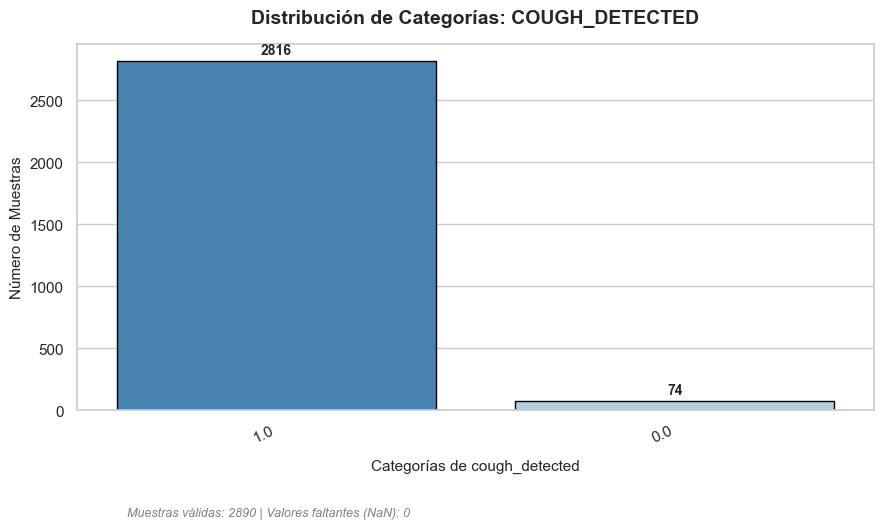

C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\1452654170.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(



--------------------------------------------------------------------------------



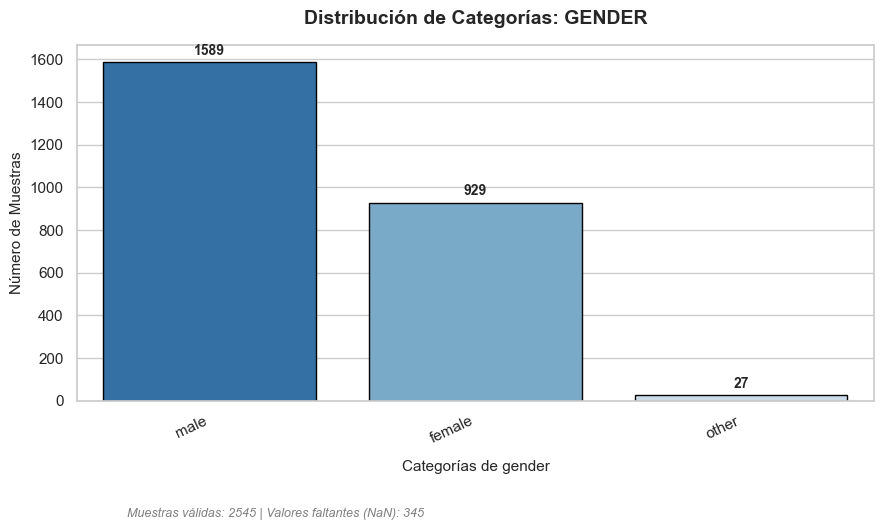


--------------------------------------------------------------------------------



C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\1452654170.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


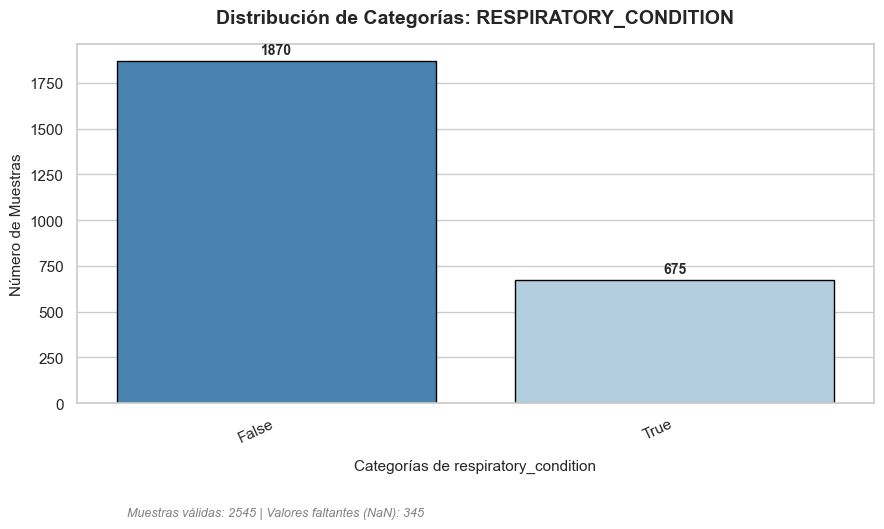


--------------------------------------------------------------------------------



C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\1452654170.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


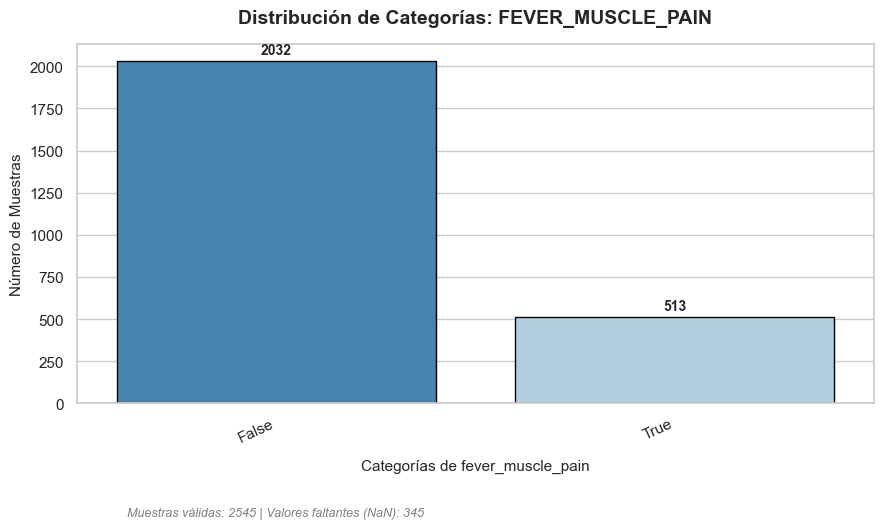


--------------------------------------------------------------------------------



C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\1452654170.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


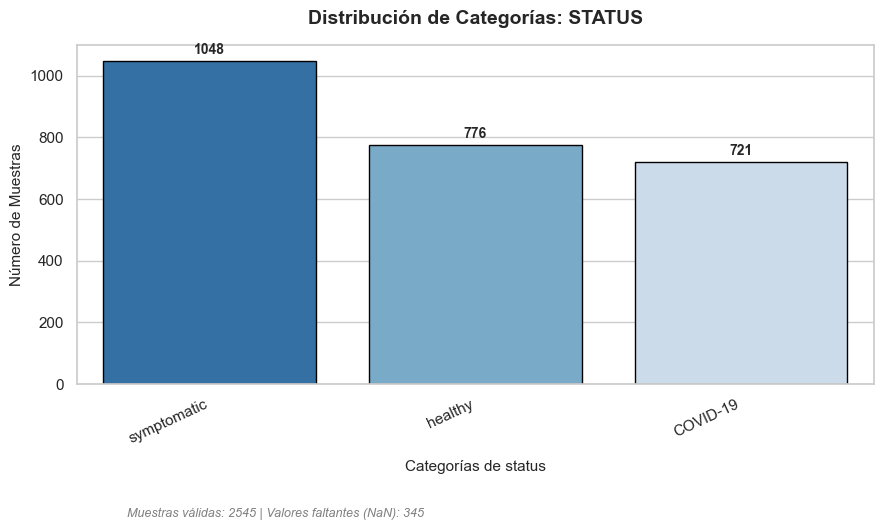


--------------------------------------------------------------------------------



C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\1452654170.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


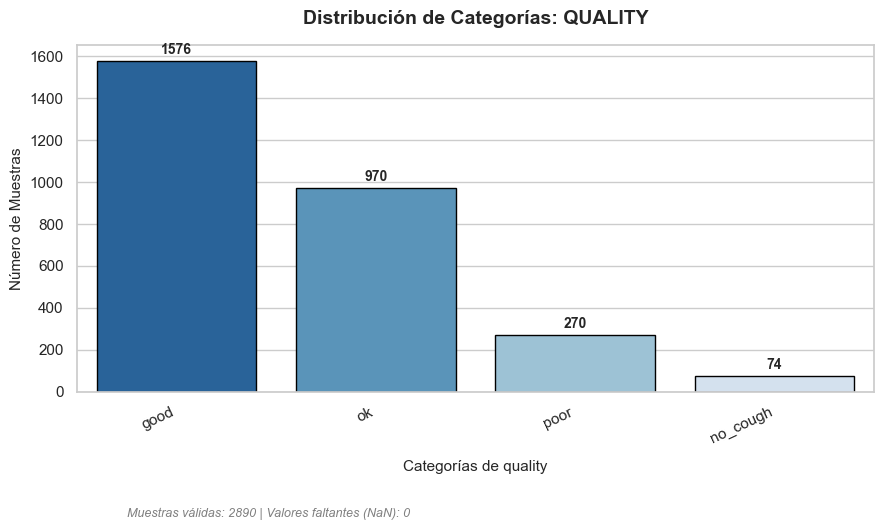

C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\1452654170.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(



--------------------------------------------------------------------------------



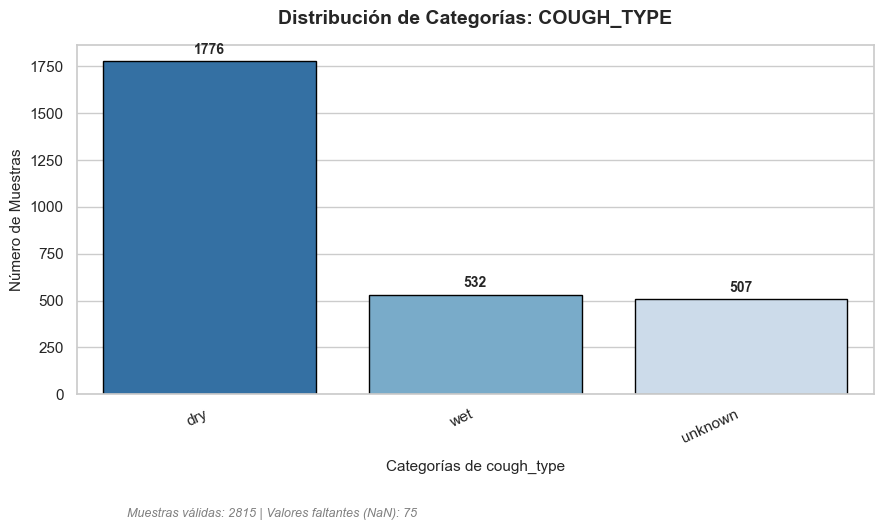


--------------------------------------------------------------------------------



C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\1452654170.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


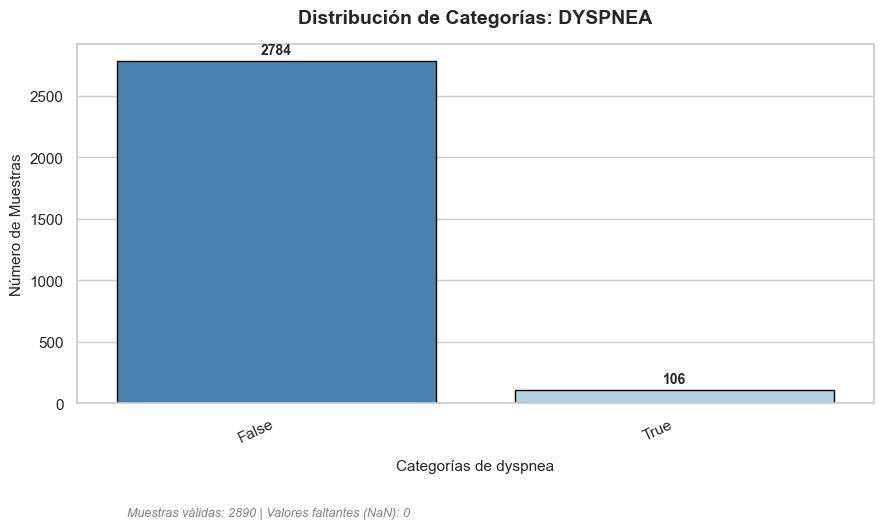


--------------------------------------------------------------------------------



C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\1452654170.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


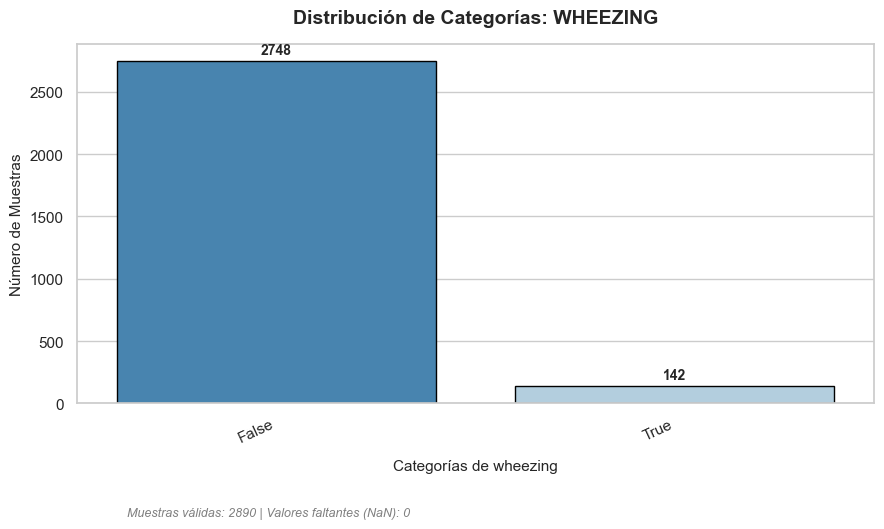

C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\1452654170.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(



--------------------------------------------------------------------------------



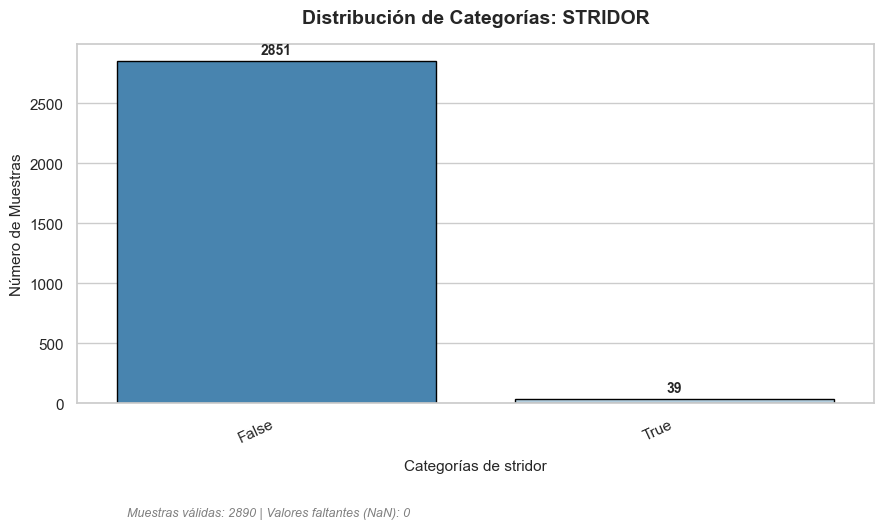


--------------------------------------------------------------------------------



C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\1452654170.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


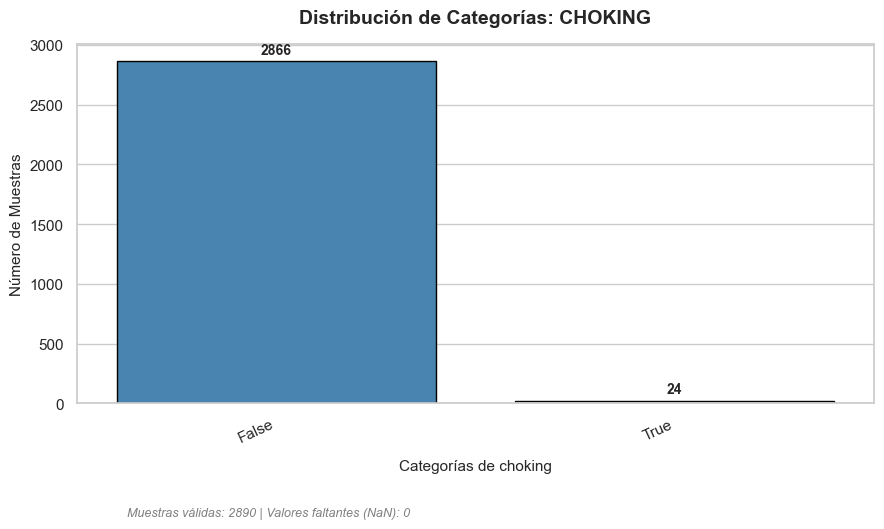


--------------------------------------------------------------------------------



C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\1452654170.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


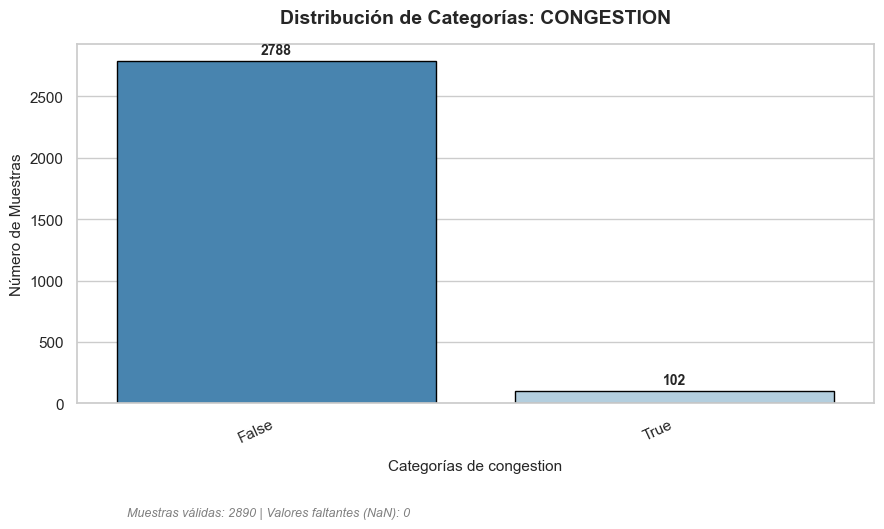


--------------------------------------------------------------------------------



C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\1452654170.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


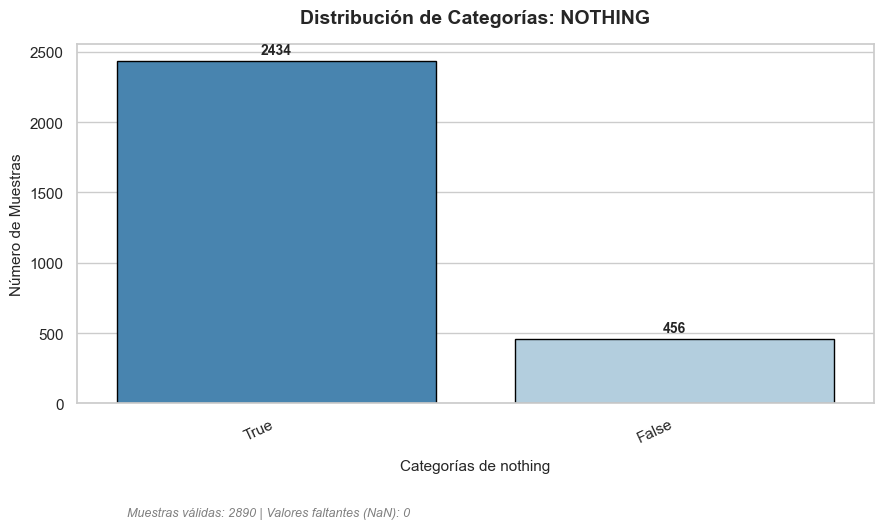


--------------------------------------------------------------------------------



C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\1452654170.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


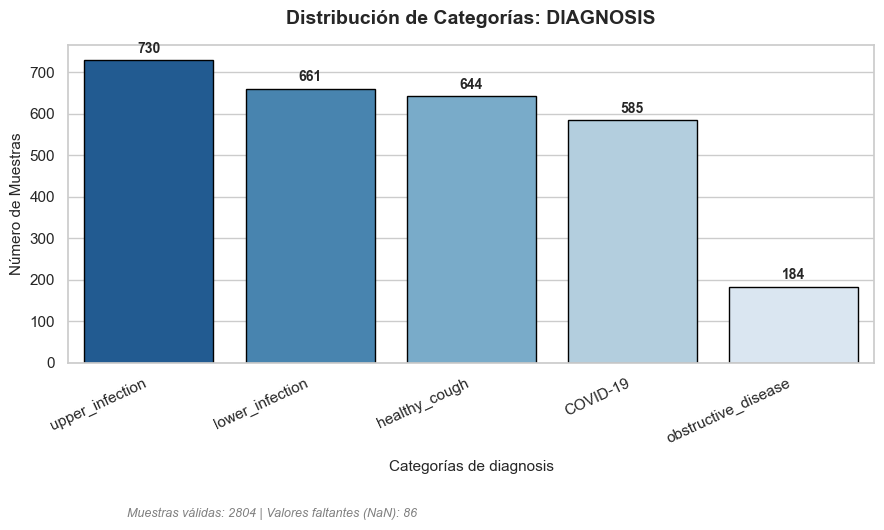


--------------------------------------------------------------------------------



C:\Users\Usuario\AppData\Local\Temp\ipykernel_38192\1452654170.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


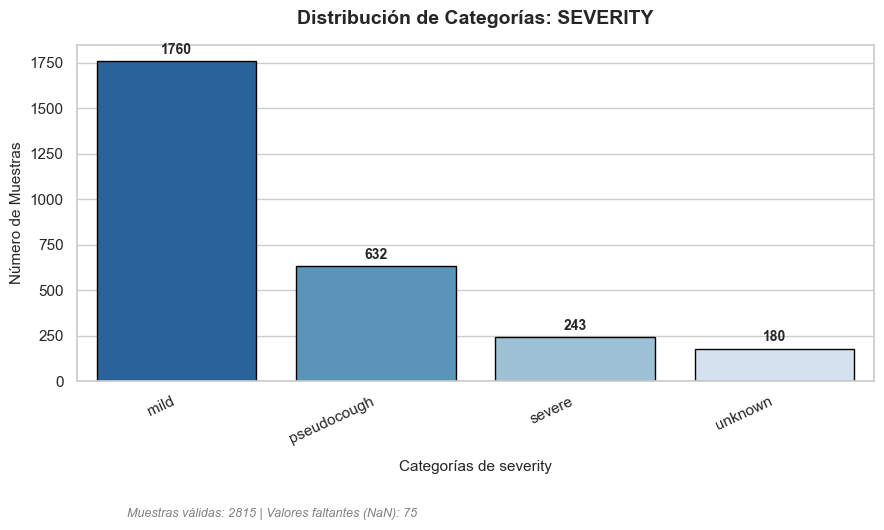


--------------------------------------------------------------------------------



In [12]:
variables_a_graficar = [
    'cough_detected', 'gender', 'respiratory_condition', 'fever_muscle_pain', 'status',
    'quality', 'cough_type', 'dyspnea', 'wheezing', 'stridor', 
    'choking', 'congestion', 'nothing', 'diagnosis', 'severity'
]

# Configuramos el estilo estético de los gráficos
sns.set_theme(style="whitegrid")

# ==============================================================================
# 2. BUCLE AUTOMÁTICO PARA GENERAR LOS DIAGRAMAS DE BARRAS
# ==============================================================================
for var in variables_a_graficar:
    # Comprobamos si la variable existe en nuestro DataFrame unificado
    if var in df_unified.columns:
        
        # Opcional: Contamos cuántos NaN hay en esta variable para reportarlo
        nans = df_unified[var].isna().sum()
        total_validos = df_unified[var].notna().sum()
        
        # Si la variable está completamente vacía en este subconjunto, nos la saltamos
        if total_validos == 0:
            print(f"⚠️ La variable '{var}' no tiene datos válidos en este split de expertos. Saltando...")
            continue
            
        # Crear la figura
        plt.figure(figsize=(9, 5))
        
        # Calcular las frecuencias ordenadas de mayor a menor para que el gráfico se vea limpio
        order = df_unified[var].value_counts().index
        
        # Dibujar el gráfico de barras (usando una paleta de colores suave y profesional)
        ax = sns.countplot(
            data=df_unified, 
            x=var, 
            order=order, 
            palette="Blues_r", 
            edgecolor="black"
        )
        
        # 3. AÑADIR ETIQUETAS DE CONTEO ENCIMA DE CADA BARRA
        for p in ax.patches:
            height = p.get_height()
            if height > 0:  # Solo ponemos número si la barra no está vacía
                ax.annotate(
                    f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', 
                    va='bottom',
                    fontsize=10, 
                    fontweight='bold',
                    xytext=(0, 3), # Margen de 3 puntos por encima de la barra
                    textcoords='offset points'
                )
        
        # Personalización de títulos y ejes
        plt.title(f"Distribución de Categorías: {var.upper()}", fontsize=14, fontweight='bold', pad=15)
        plt.xlabel(f"Categorías de {var}", fontsize=11, labelpad=10)
        plt.ylabel("Número de Muestras", fontsize=11)
        
        # Rotar las etiquetas del eje X si son strings largos (como en 'diagnosis' o 'features_description')
        plt.xticks(rotation=25, ha='right')
        
        # Añadir un texto sutil abajo indicando los datos válidos y los NaNs
        plt.figtext(0.15, -0.05, f"Muestras válidas: {total_validos} | Valores faltantes (NaN): {nans}", 
                    fontsize=9, style='italic', color='gray')
        
        # Ajustar el diseño para que no se corten los textos y mostrar gráfico
        plt.tight_layout()
        plt.show()
        print("\n" + "-"*80 + "\n")